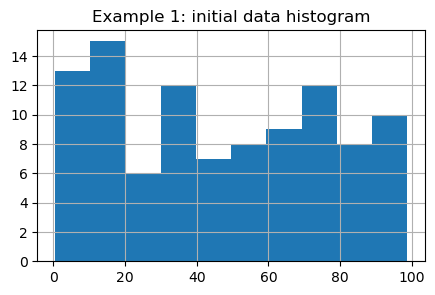

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

np.random.seed(42)

data = pd.Series(np.random.rand(100) * 100)

data.hist(figsize=(5, 3))
plt.title("Example 1: initial data histogram")
plt.show()

In [2]:
upper_quantiles = []
lower_quantiles = []
for i in range(1000):
    subsample = data.sample(frac=1, replace=True)
    upper_quantiles.append(subsample.quantile(0.99))
    lower_quantiles.append(subsample.quantile(0.01))

upper_quantiles = pd.Series(upper_quantiles)
lower_quantiles = pd.Series(lower_quantiles)

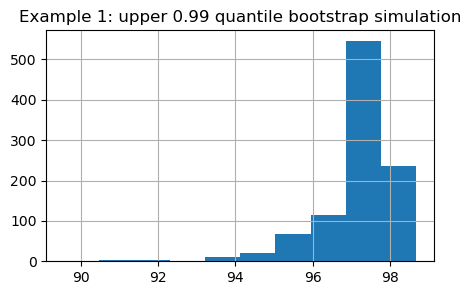

In [3]:
upper_quantiles.hist(figsize=(5, 3))
plt.title("Example 1: upper 0.99 quantile bootstrap simulation")
plt.show()

In [4]:
# upper 0.99 quantile lies in this interval with 95% confidence
print(f'{upper_quantiles.quantile(0.025):.2f}') # Out: 94.89
print(f'{upper_quantiles.quantile(0.975):.2f}') # Out: 98.69

# lower 0.01 quantile lies in this interval with 95% confidence
print(f'{lower_quantiles.quantile(0.025):.2f}') # Out: 0.55
print(f'{lower_quantiles.quantile(0.975):.2f}') # Out: 4.62

94.89
98.69
0.55
4.62


In [76]:
# generate 2 samples
mean1,std1 = 7,3
mean2,std2 = 6.5,3

samples_A = np.maximum(0,np.random.normal(mean1,std1,100))
samples_B = np.maximum(0,np.random.normal(mean2,std2,100))

plt.show()

(array([ 3.,  6., 10., 21., 28., 12., 12.,  5.,  2.,  1.]),
 array([ 0.        ,  1.51626069,  3.03252138,  4.54878207,  6.06504276,
         7.58130345,  9.09756415, 10.61382484, 12.13008553, 13.64634622,
        15.16260691]),
 <BarContainer object of 10 artists>)

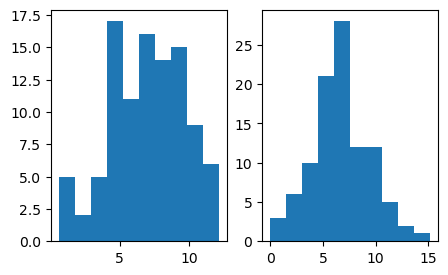

In [77]:
f,ax=plt.subplots(1,2,figsize=(5,3))
ax[0].hist(samples_A)
ax[1].hist(samples_B)

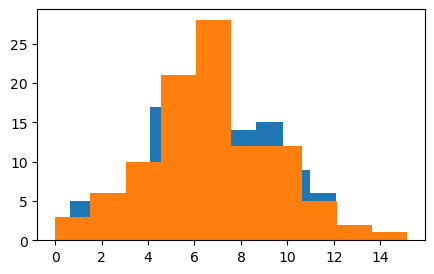

In [78]:
f,ax=plt.subplots(1,1,figsize=(5,3))
ax.hist(samples_A)
ax.hist(samples_B)

obs_diff = np.mean(samples_B) - np.mean(samples_A)


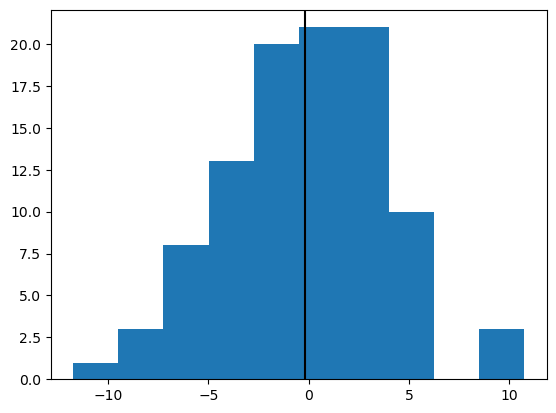

In [79]:
plt.hist(samples_B-samples_A)
plt.axvline(x = obs_diff,color='k')

(-0.8874465542988141, 0.536715136838087)
0.482


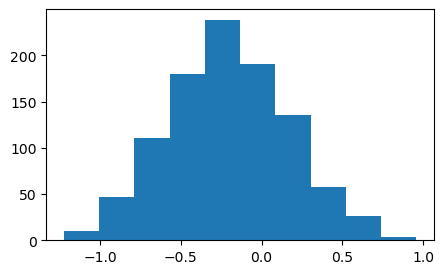

In [80]:
boots_difference = []
nsamples = 1000
for n in range(nsamples):
    boot1 = np.random.choice(samples_A,size=len(samples_A),replace=True)
    boot2 = np.random.choice(samples_B,size=len(samples_B),replace=True)
    boots_difference.append(np.mean(boot2) - np.mean(boot1))

ci = 95
# Compute confidence interval
lower = np.percentile(boots_difference, 2.5)
upper = np.percentile(boots_difference, 97.5)
conf_int = (lower, upper)
print(conf_int)

count = 0
for val in boots_difference:
    if val >= obs_diff:
        count += 1
        
# p_boots = np.mean(np.abs(boots_difference) >= np.abs(obs_diff))
p_value = count / nsamples
f,ax=plt.subplots(1,1,figsize=(5,3))
ax.hist(boots_difference)

print(p_value)